# Conos: adjusting alignment strength

By default Conos aligns samples gently — it corrects obvious batch
differences while preserving each sample’s structure. Sometimes that
isn’t enough: samples from different tissues or conditions still form
**sample-specific sub-clusters** within a shared cell type. When that
residual separation is batch rather than biology, you can pull the
samples together more forcefully. This tutorial covers the two knobs for
that — the `alignment.strength` dial and **“supervised” alignment** that
down-weights edges within a chosen factor — on the bone-marrow (BM) /
cord-blood (CB) panel.

A word of caution up front: stronger alignment trades structure for
mixing. Push it too far and genuinely distinct populations get merged.
Always sanity-check that the populations you care about stay separated.

## At a glance

``` r
# pull samples together more forcefully (0 = none ... 1 = maximum):
con$runGraph(alignment.strength = 0.3)

# or align only *across* a chosen factor (e.g. tissue), down-weighting within-factor edges:
con$runGraph(balancing.factor.per.cell = tissue, same.factor.downweight = 0.1, alignment.strength = 0.3)
```

## Contents

- [Setup](#setup)
- [A baseline alignment](#a-baseline-alignment)
- [Turning up the alignment
  strength](#turning-up-the-alignment-strength)
- [Supervised alignment](#supervised-alignment)
- [Choosing a value](#choosing-a-value)

## Setup

Load the panel, down-sample for speed, and pre-process each sample into
a `Pagoda2` object with a PCA reduction (as in the
[walkthrough](conos-walkthrough.ipynb)).

In [ ]:
library(conos)
library(pagoda2)

set.seed(1)
panel <- lapply(conosPanel::panel, function(m) m[, sample(ncol(m), 600)])
samples <- lapply(panel, function(cm) {
  Pagoda2$from(cm, verbose = FALSE)$run(steps = c("variance", "pca"), verbose = FALSE)
})
con <- Conos$new(samples, n.cores = 1)

## A baseline alignment

Build the joint graph with the defaults and embed it. Colouring the
embedding by **sample** is how we judge alignment: well-aligned samples
interleave; residual batch shows up as sample-specific regions.

In [ ]:
con$runGraph(k = 20, k.self = 5, space = "PCA", ncomps = 30, verbose = FALSE)
con$runEmbedding(method = "UMAP", embedding.name = "default", min.visited.verts = 100, verbose = FALSE)

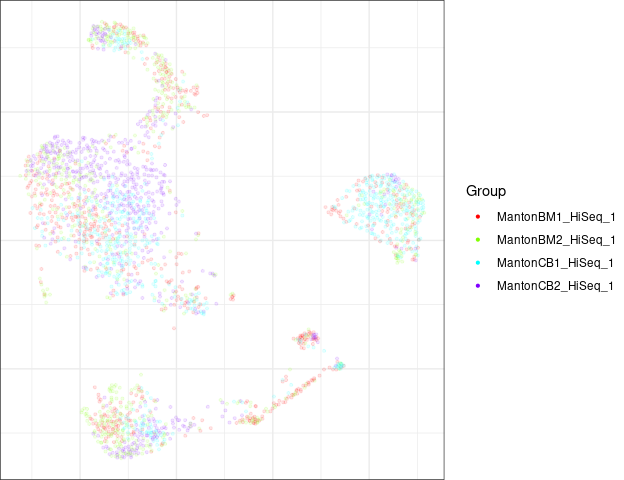

In [ ]:
con$plotGraph(embedding = "default", color.by = "sample", mark.groups = FALSE, alpha = 0.1, show.legend = TRUE)

The four samples mostly overlap, but some regions are dominated by one
tissue — the kind of residual separation `alignment.strength` can
reduce.

## Turning up the alignment strength

`alignment.strength` runs from 0 (the gentle default behaviour) to 1
(maximum). Higher values pull mutual neighbours across samples together
more aggressively. Rebuild the graph at a moderate value and re-embed
(into a separately named embedding so we can compare):

In [ ]:
con$runGraph(k = 20, k.self = 5, space = "PCA", ncomps = 30, alignment.strength = 0.3, verbose = FALSE)
con$runEmbedding(method = "UMAP", embedding.name = "strength_0.3", min.visited.verts = 100, verbose = FALSE)

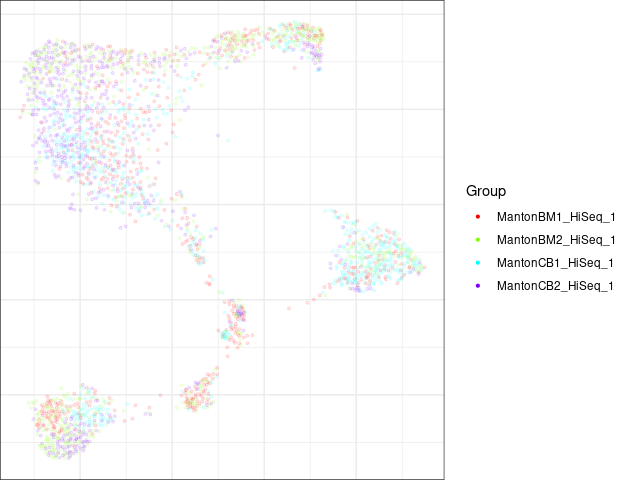

In [ ]:
con$plotGraph(embedding = "strength_0.3", color.by = "sample", mark.groups = FALSE, alpha = 0.1, show.legend = TRUE)

The samples are noticeably more interleaved. Pushing further
(e.g. `alignment.strength = 0.7`) mixes them even more tightly — but
watch for distinct populations starting to collapse together:

In [ ]:
con$runGraph(k = 20, k.self = 5, space = "PCA", ncomps = 30, alignment.strength = 0.7, verbose = FALSE)
con$runEmbedding(method = "UMAP", embedding.name = "strength_0.7", min.visited.verts = 100, verbose = FALSE)

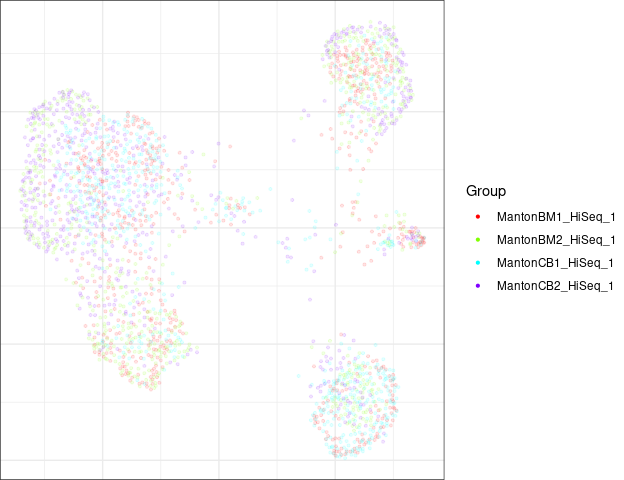

In [ ]:
con$plotGraph(embedding = "strength_0.7", color.by = "sample", mark.groups = FALSE, alpha = 0.1, show.legend = TRUE)

## Supervised alignment

Sometimes you know *which* factor the unwanted separation follows —
here, **tissue** (BM vs CB). Instead of turning up global strength, you
can tell Conos to **down-weight edges within that factor**, so the
alignment works hardest *across* it. Build a per-cell tissue label from
the sample names:

In [ ]:
tissue <- ifelse(grepl("BM", con$getDatasetPerCell()), "BM", "CB")
tissue <- setNames(factor(tissue), names(con$getDatasetPerCell()))
table(tissue)

tissue
  BM   CB 
1195 1181 

`balancing.factor.per.cell` names the factor and
`same.factor.downweight` (\< 1) scales down within-factor edges — so
cross-tissue links carry relatively more weight:

In [ ]:
con$runGraph(k = 20, k.self = 5, space = "PCA", ncomps = 30,
             balancing.factor.per.cell = tissue, same.factor.downweight = 0.1,
             alignment.strength = 0.3, verbose = FALSE)
con$runEmbedding(method = "UMAP", embedding.name = "supervised", min.visited.verts = 100, verbose = FALSE)

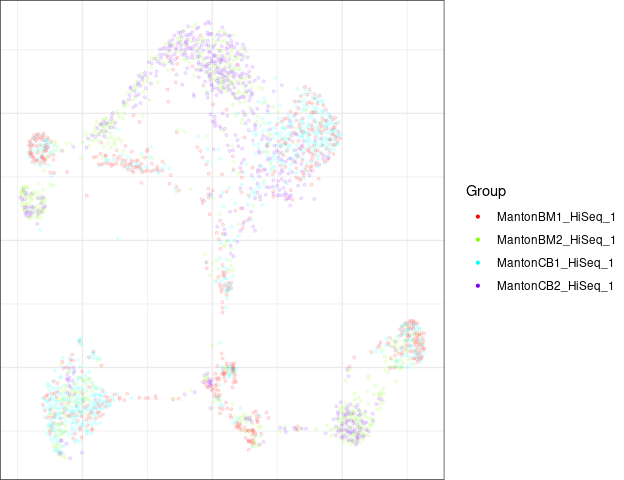

In [ ]:
con$plotGraph(embedding = "supervised", color.by = "sample", mark.groups = FALSE, alpha = 0.1, show.legend = TRUE)

This targets the BM↔CB difference specifically, mixing across tissues
without forcing every sample together as hard as a high global
`alignment.strength` would.

## Choosing a value

Reach for these only when the sample-mixing plot shows batch-like
separation the default didn’t remove:

- start from the **default** (no `alignment.strength`); raise it
  gradually (0.2–0.4 is usually plenty);
- prefer **supervised** alignment when you can name the nuisance factor
  (tissue, donor, batch) — it corrects that axis without over-mixing
  everything;
- after any change, re-run `runClustering()` and check markers
  (`plotMarkerDotPlot()`): if previously distinct populations have
  merged, you’ve gone too far.

The defaults are deliberately conservative — most panels need only a
small nudge, if any.